# Issue 08 — Quiet Luxury vs. Loud Luxury: Trend Interest Test Pull

**Purpose of this notebook:**  
Test whether Google Trends has a clean, usable signal for `quiet luxury` vs. a "logomania"/loud luxury revival term before locking the hook stat mechanism for Issue #8. This is a test pull and not the final branded analysis notebook, exploratory only.

## 1. Setup

In [1]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")  

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from trendspy import Trends

RAW_DIR = Path("../../../data/raw/cycle 2/issue-08")
PROCESSED_DIR = Path("../../../data/processed/cycle 2/issue-08")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load brand palette

In [3]:
# load brand palette
with open("../../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

## 3. Extracting / analyzing data

Candidate terms to test (swap/add terms here if the first pass comes back sparse or noisy.)  
`quiet luxury` should have a strong, well-documented 2022–2023 spike. The loud-luxury/logomania side is the term most likely to need iteration, since it's less standardized language than "quiet luxury" was.

In [ ]:
tr = Trends()

TERMS = ["quiet luxury", "logomania", "loud luxury"]
TIMEFRAME = "2019-01-01 2026-09-01"

try:
    df = tr.interest_over_time(TERMS, timeframe=TIMEFRAME)
except Exception as e:
    # surface the actual error response before debugging further,
    # don't assume the exception message alone tells the full story.
    print(f"Pull failed: {e}")
    raise

df.head()

,quiet luxury,logomania,loud luxury,isPartial
time [UTC],,,,
2019-01-01,1,2,26,False
2019-02-01,1,2,23,False
2019-03-01,1,2,21,False
2019-04-01,1,2,17,False
2019-05-01,1,2,13,False


In [7]:
# save the raw pull
raw_path = RAW_DIR / "quiet_vs_loud_luxury_interest.csv"
df.to_csv(raw_path)
print(f"Saved raw pull to {raw_path}")

Saved raw pull to ..\..\..\data\raw\cycle 2\issue-08\quiet_vs_loud_luxury_interest.csv


In [ ]:
# find the last 6 rows to examine the spike in quiet luxury
df.tail(6)

,quiet luxury,logomania,loud luxury,isPartial
time [UTC],,,,
2026-04-01,67,2,12,False
2026-05-01,100,2,12,False
2026-06-01,71,2,13,False
2026-07-01,57,2,11,False
2026-08-01,32,5,8,False
2026-09-01,23,3,6,True


## 4. Plot

At this stage, only exploratory analysis is conducted.
- Checking signal quality (sparse? noisy? does a real
peak-and-decline shape show up for quiet luxury, and does anything on the loud-luxury/logomania side show a rise?) before deciding whether this mechanism is sourceable enough to build the final branded chart.

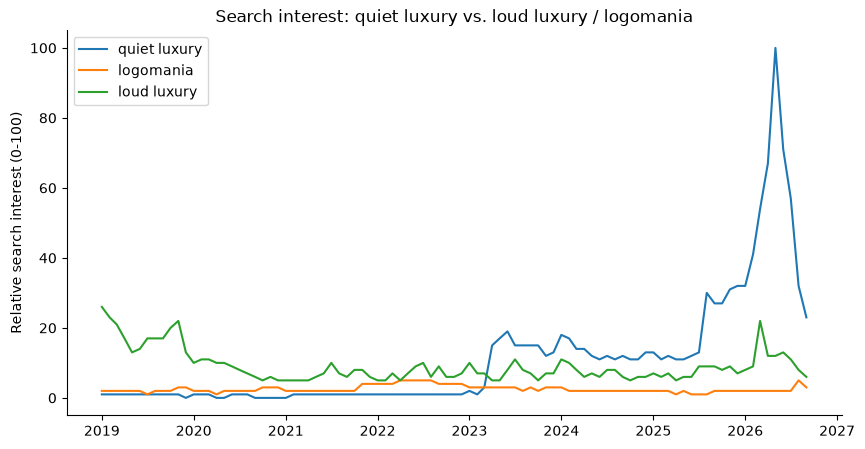

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for term in TERMS:
    if term in df.columns:
        ax.plot(df.index, df[term], label=term)
ax.set_title("Search interest: quiet luxury vs. loud luxury / logomania")
ax.set_ylabel("Relative search interest (0-100)")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

## 4. Findings

- **Does `quiet luxury` show a clean 2022–2023 rise-and-fall shape?**  
  No. It stays near zero until ~2023, climbs steadily through 2023–2025, then spikes sharply to a peak of
  100 in May 2026, followed by a real decline (100 → 71 → 57 → 32 across June–August 2026, all complete months, not partial data). The original 2022–2023 peak assumption doesn't
  hold, the real story is a ~3-year build followed by a ~4-month burn, peaking in 2026, not 2022–2023.
- **Does any loud-luxury/logomania term show a corresponding rise?**  
  No. `logomania` sits flat near 0–5 for the entire 2019–2026 window, no usable signal at all. `loud luxury`
  actually declines from 2019–2021, then rises only slightly and stays low (roughly 8–13) from 2022 onward, moving *alongside* quiet luxury rather than opposite it. Neither
  term supports a "swing back to loud luxury" narrative. No alternate term wording was tested, since the build-time/burn-time reframing (below) no longer needs one.
- **Is the signal clean enough to support the hook stat, or does this mechanism need to be dropped/reworked?**  
  The original "quiet luxury rose, then got displaced by its opposite" mechanism is dropped, it isn't supported by this data. What the data does support, and arguably more cleanly: 
  a trend that took years to build can now complete an entire rise-and-fall cycle in a few months once it breaks through. Reframing beat 3 around build time vs. burn time, using `quiet luxury`'s own curve, rather than framing it against a manufactured opposite. `logomania` and `loud luxury` are dropped from the story entirely.
- **Data quality note:**  
  The 2026-09-01 row is `isPartial = True` and should be excluded or treated with caution in any chart/analysis, it may shift once the month closes. The
  May–August 2026 decline is confirmed on complete months and doesn't depend on that partial row.